In [49]:
import time
from datetime import datetime
import numpy as np
from collections import deque, namedtuple
import collections
import os
import time
import shutil
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import cv2
import gymnasium as gym
import gymnasium.spaces
import torch.onnx
from torch.serialization import load

import matplotlib.pyplot as plt
import copy
%matplotlib inline

from matplotlib import animation
import seaborn as sns; sns.set()
from IPython.display import clear_output, HTML
from IPython import display

import onnx
from onnx2pytorch import ConvertModel

from minigrid.wrappers import ImgObsWrapper


In [50]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer():
  def __init__(self, num_actions, memory_len = 10000):
      self.memory_len = memory_len
      self.transition = []
      self.num_actions = num_actions

  def add(self, state, action, reward, next_state, done):
      if self.length() > self.memory_len:
        self.remove()
      self.transition.append(Transition(state, action, reward, next_state, done))

  def sample_batch(self, batch_size = 32):
      minibatch = random.sample(self.transition, batch_size)
      states_mb, a_, reward_mb, next_states_mb, done_mb = map(np.array, zip(*minibatch))

      mb_reward = torch.from_numpy(reward_mb).to(device=device, dtype=torch.float32)
      mb_done = torch.from_numpy(done_mb.astype(int)).to(device=device)
      a_ = a_.astype(int)
      a_mb = np.zeros((a_.size, self.num_actions), dtype=np.float32)
      a_mb[np.arange(a_.size), a_] = 1
      mb_a = torch.from_numpy(a_mb).cuda().to(device=device)
      return states_mb, mb_a, mb_reward, next_states_mb, mb_done # states will be converted to tensors in forward pass

  def length(self):
      return len(self.transition)

  def remove(self):
      self.transition.pop(0)


class ChannelFirst(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        old_shape = env.observation_space.shape
        self.observation_space = {}
        self.observation_space = gym.spaces.Box(0, 255, shape=(3, 7, 7))

    def observation(self, observation):
        return np.swapaxes(observation, 2, 0)

class ScaledFloatFrame(gym.ObservationWrapper):
    def __init__(self, env):
        gym.ObservationWrapper.__init__(self, env)

    def observation(self, observation):
        # careful! This undoes the memory optimization, use
        # with smaller replay buffers only.
        return np.array(observation).astype(np.float32)

class MinigridEmpty5x5ImgObs(gym.Wrapper):
    """Minigrid with image observations provided by minigrid, partially observable."""
    def __init__(self, render=False):
        if render:
          env = gym.make('MiniGrid-Empty-5x5-v0', render_mode="rgb_array")
        else:
          env = gym.make('MiniGrid-Empty-5x5-v0')
        env = ScaledFloatFrame(ChannelFirst(ImgObsWrapper(env)))
        super().__init__(env)

class MinigridDoorKey6x6ImgObs(gym.Wrapper):
    """Minigrid with image observations provided by minigrid, partially observable."""
    def __init__(self, render=False):
        if render:
          env = gym.make('MiniGrid-DoorKey-6x6-v0', render_mode="rgb_array")
        else:
          env = gym.make('MiniGrid-DoorKey-6x6-v0')
        env = ScaledFloatFrame(ChannelFirst(ImgObsWrapper(env)))
        super().__init__(env)


class MlpMinigridPolicy(nn.Module):
    def __init__(self, num_actions=7):
        super().__init__()
        self.num_actions = num_actions
        self.fc = nn.Sequential(nn.Flatten(),
                                nn.Linear(3*7**2, 256), nn.ReLU(),
                                nn.Linear(256, 256), nn.ReLU(),
                                nn.Linear(256, 64), nn.ReLU(),
                                nn.Linear(64, num_actions))
    def forward(self, x):
        if len(x.size()) == 3:
          x = x.unsqueeze(dim=0)
        return self.fc(x)


class ConvMinigridPolicy(nn.Module):
    def __init__(self, num_actions=7):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=2),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=2),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.LazyLinear(128),
            nn.ReLU(),
            nn.LazyLinear(num_actions)
        )

    def forward(self, x):
        if len(x.size()) == 5:
            x = x.squeeze(dim=0)
        if len(x.size()) == 3:
          x = x.unsqueeze(dim=0)

        return self.conv(x)


def plot(frame_idx, rewards, losses):
    clear_output(True)
    plt.figure(figsize=(20,5))
    plt.subplot(131)
    plt.title('frame %s. reward: %s' % (frame_idx, np.mean(rewards[-10:])))
    plt.plot(rewards)
    plt.subplot(132)
    plt.title('loss')
    plt.plot(losses)
    plt.show()

def set_seed(env, seed=None):
    if seed is not None:
        random.seed(seed)
        env.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)


def load_checkpoint(checkpoint_path='', device=device):
  dqn = MlpMinigridPolicy(num_actions=num_actions).to(device=device)
  dqn_target = MlpMinigridPolicy(num_actions=num_actions).to(device=device)
#   dqn = ConvMinigridPolicy(num_actions=num_actions).to(device=device)
#   dqn_target = ConvMinigridPolicy(num_actions=num_actions).to(device=device)
  timesteps = 0

  if checkpoint_path:
    print(f'Loading checkpoint {checkpoint_path}')
    checkpoint_dict = torch.load(checkpoint_path, map_location=device)
    model_params = checkpoint_dict['model_params']
    timesteps = checkpoint_dict['timesteps'] # environment steps

    dqn.load_state_dict(model_params) # makes a copy of model_params
    dqn_target.load_state_dict(model_params)
  else:
    print(f'Starting training from scratch.')

  return dqn, dqn_target, timesteps

def store_checkpoint(checkpoint_path, dqn_net, timesteps):
  checkpoint_dict = {'model_params':dqn_net.state_dict(), 'timesteps': timesteps}
  torch.save(checkpoint_dict, checkpoint_path)


def soft_update(local_model, target_model, tau):
    """Soft update model parameters.
    θ_target = τ*θ_local + (1 - τ)*θ_target
    Params
    ======
        local_model (PyTorch model): weights will be copied from
        target_model (PyTorch model): weights will be copied to
        tau (float): interpolation parameter
    """
    # TODO: Update target network
    with torch.no_grad():
        for target_param, local_param in zip(target_model.parameters(), local_model.parameters()):
            target_param.data.copy_(tau * local_param.data + (1.0 - tau) * target_param.data)


def save_as_onnx(torch_model, sample_input, model_path):
    torch.onnx.export(torch_model,             # model being run
                    sample_input,              # model input (or a tuple for multiple inputs)
                    f=model_path,              # where to save the model (can be a file or file-like object)
                    export_params=True,        # store the trained parameter weights inside the model file
                    opset_version=17,          # the ONNX version to export the model to - see https://github.com/microsoft/onnxruntime/blob/master/docs/Versioning.md
                    do_constant_folding=True,  # whether to execute constant folding for optimization
                    external_data=False,       # keeps everything in a single .onnx file, needed if you are using torch version 2.5 or newer, comment out otherwise
                    )

cuda


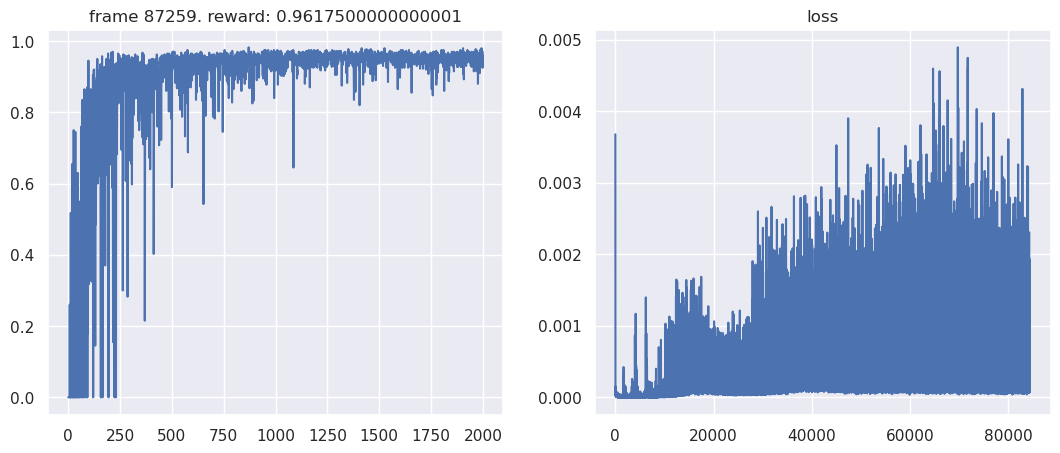

In [51]:
num_episodes = 2000 # number of episodes to run the algorithm -> the algorithm should reach a score of about 0.9 within 1000 episodes
buffer_size = 100000 # size of the buffer to use
epsilon = 1.0 # initial probablity of selecting random action a, annealed over time
timesteps = 0 # counter for number of frames
minibatch_size = 128 # size of the minibatch sampled
gamma = 0.95 # discount factor
eval_episode = 100
num_eval = 10
tau = 1e-3
learning_rate = 4e-4
update_after = 2000 # update after num time steps
epsilon_decay = 100000 # decay epsilon in 100.000 timesteps
epsilon_ub = 1.0
epsilon_lb = 0.3
# set seed
np.random.seed(0)
torch.manual_seed(0)

load_path = ""
save_path = f"minigrid-model-{datetime.now().strftime('%Y_%m_%d-%H_%M_%S')}.p"

env = MinigridDoorKey6x6ImgObs()
obs = env.reset()[0]

num_actions = env.action_space.n
state_space = env.observation_space.shape

# Train the agent using DQN for Pong
returns = []
returns_50 = deque(maxlen=50)
losses = []
buffer = ReplayBuffer(num_actions=num_actions, memory_len=buffer_size)

dqn, dqn_target, timesteps = load_checkpoint(load_path)
optimizer = optim.Adam(dqn.parameters(), lr=learning_rate)
# mse = torch.nn.MSELoss()
state = env.reset()[0]
has_won = False
for i in range(num_episodes):
  ret = 0
  done = False
  while not done:
    # Decay epsilon
    epsilon = max(epsilon_lb, epsilon_ub - timesteps/ epsilon_decay)
    # action selection
    if np.random.choice([0,1], p=[1-epsilon,epsilon]) == 1:
      a = np.random.randint(low=0, high=num_actions, size=1)[0]
    else:
      # state_tmp = state[np.newaxis, :].astype(np.float32)
      state_tensor = torch.tensor(state, dtype=torch.float32, device=device)
      net_out = dqn(state_tensor).detach().cpu().numpy()
      a = np.argmax(net_out)
#    next_state, r, done, info = env.step(a)
    next_state, r, terminated, truncated, info = env.step(a)
    done = terminated or truncated
#    print(next_state.shape)
    ret = ret + r
    # TODO: store transition in replay buffer
    buffer.add(state, a, r, next_state, done)
    state = next_state
    timesteps = timesteps + 1

    if r > 0 and not has_won:
      print(f"First win at step {timesteps}")
      has_won = True

    # update policy using temporal difference
    if buffer.length() > minibatch_size and buffer.length() > update_after and has_won:
      optimizer.zero_grad()
      # TODO: Sample a minibatch randomly
      states_mb, actions_mb, rewards_mb, next_state_mb, done_mb = buffer.sample_batch(minibatch_size)
      # TODO: Compute q values for states
      q_values = dqn(torch.tensor(states_mb, dtype=torch.float32, device=device))
      # TODO: compute the targets for training
      with torch.no_grad():
        q_values_next = dqn_target(torch.tensor(next_state_mb, dtype=torch.float32, device=device))
        max_q_values_next = torch.max(q_values_next, dim=1)[0]
      targets = rewards_mb + gamma * (1 - done_mb) * max_q_values_next
      # TODO: compute the predictions for training
      predictions = torch.sum(q_values * actions_mb, dim=1)
      # TODO: Compute loss: mse = mean squared error
      loss = F.smooth_l1_loss(predictions, targets)
      # print('predictions', predictions, 'targets', targets)
      # print(loss)
      losses.append(loss.item())
      loss.backward()
      torch.nn.utils.clip_grad_norm_(dqn.parameters(), 10.0)
      optimizer.step()
      # Update target network
      soft_update(dqn, dqn_target, tau)
    if done:
      state = env.reset()[0]
      # print(f"Episode: \t{i}\t{ret}\t{datetime.now().strftime('%Y_%m_%d-%H_%M_%S')}")
      break
  returns.append(ret)
  returns_50.append(ret)
  if i % 50 == 0:
    store_checkpoint(checkpoint_path=save_path, dqn_net=dqn, timesteps=timesteps)
    print('\rEpisode {}\tAverage Score: {:.2f}'.format(i, np.mean(returns_50)))


seed = np.random.randint(1e7)
sample_state = env.reset(seed=seed)[0]
save_as_onnx(dqn, torch.tensor(sample_state, dtype=torch.float32, device=device).unsqueeze(0), 'submission_model_new.onnx')
plot(timesteps, returns, losses)

Evaluate your model:

In [52]:
class Agent():
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def select_action(self, state):
        state = np.expand_dims(state, 0)
        state = torch.tensor(state, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            q_action = self.model(state).detach().cpu().numpy()

            return np.argmax(q_action)

def run_episode(env, agent, seed=None):
    state = env.reset(seed=seed)[0]
    score = 0
    done = False
    while not done:
        action = agent.select_action(state)
        state, reward, terminated, truncated, _ = env.step(action)
        score += reward
        done = terminated or truncated
    env.close()
    return score


In [53]:


dqn = ConvertModel(onnx.load('submission_model_new.onnx'))
dqn = dqn.to(device)
dqn.eval()

agent = Agent(model=dqn, device=device)

N_EPISODES = 50
scores = []
for i in range(N_EPISODES):
    seed = np.random.randint(1e7)
    scores.append(run_episode(env, agent, seed=seed))


print("Average Return:", np.mean(scores))



Average Return: 0.97015
